In [ ]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(123)
np.random.seed(123)

In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_map = {
    "n0000": "anoectochilus burmanicus rolfe.",
    "n0001": "bulbophyllum auricomum lindl.",
    "n0002": "bulbophyllum dayanum rchb",
    "n0003": "bulbophyllum lasiochilum par. & rchb",
    "n0004": "bulbophyllum limbatum",
    "n0005": "bulbophyllum longissimum (ridl.) ridl",
    "n0006": "bulbophyllum medusae (lindl.) rchb",
    "n0007": "bulbophyllum patens king ex hk.f.",
    "n0008": "bulbophyllum rufuslabram",
    "n0009": "bulbophyllum siamensis rchb",
    "n0010": "calenthe rubens",
    "n0011": "chiloschista parishii seidenf.",
    "n0012": "chiloschista viridiflora seidenf.",
    "n0013": "cymbidium aloifolium (l.) sw.",
    "n0014": "dendrobium chrysotoxum lindl",
    "n0015": "dendrobium farmeri paxt.",
    "n0016": "dendrobium fimbriatum hook",
    "n0017": "dendrobium lindleyi steud",
    "n0018": "dendrobium pulchellum roxb",
    "n0019": "dendrobium pulchellum",
    "n0020": "dendrobium secundum bl-lindl",
    "n0021": "dendrobium senile par. & rchb.f.",
    "n0022": "dendrobium signatum rchb. f",
    "n0023": "dendrobium thyrsiflorum rchb. f.",
    "n0024": "dendrobium tortile lindl",
    "n0025": "dendrobium tortile",
    "n0026": "hygrochillus parishii var. marrioftiana (rchb.f.)",
    "n0027": "paphiopedilum bellatulum",
    "n0028": "paphiopedilum callosum",
    "n0029": "paphiopedilum charlesworthii",
    "n0030": "paphiopedilum concolor",
    "n0031": "paphiopedilum exul",
    "n0032": "paphiopedilum godefroyae",
    "n0033": "paphiopedilum gratrixianum",
    "n0034": "paphiopedilum henryanum",
    "n0035": "paphiopedilum intanon-villosum",
    "n0036": "paphiopedilum niveum (rchb.f.) stein",
    "n0037": "paphiopedilum parishii",
    "n0038": "paphiopedilum spicerianum",
    "n0039": "paphiopedilum sukhakulii",
    "n0040": "pelatantheria bicuspidata (rolfe ex downie) tang & wang",
    "n0041": "pelatantheria insectiflora (rchb.f.) ridl.",
    "n0042": "phaius tankervilleae (banks ex i' heritier) blume",
    "n0043": "phalaenopsis cornucervi (breda) bl. & rchb.f.",
    "n0044": "rhynchostylis gigantea (lindl.) ridl.",
    "n0045": "trichoglottis orchideae (koern) garay.",
    "n0046": "bulbophyllum auratum lindl.",
    "n0047": "bulbophyllum morphologorum f.kranzl.",
    "n0048": "dendrobium cumulatum lindl.",
    "n0049": "maxiralia tenui folia",
    "n0050": "paphiopedilum vejvarutianum o. gruss & roellke",
    "n0051": "oncidium goldiana"
}


In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/DL Project/Flowers train-20251011T083748Z-1-001/Flowers train"
TEST_DIR  = "/content/drive/MyDrive/DL Project/Flowers test-20251011T083724Z-1-001/Flowers test"

In [ ]:
def list_class_folders(path):
    classes = [d for d in sorted(os.listdir(path)) if os.path.isdir(os.path.join(path, d))]
    return classes

train_classes = list_class_folders(TRAIN_DIR)
test_classes  = list_class_folders(TEST_DIR)
print("Detected train classes (count={}):".format(len(train_classes)), train_classes)
print("Detected test classes (count={}):".format(len(test_classes)), test_classes)


Detected train classes (count=52): ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n0051']
Detected test classes (count=52): ['n0000', 'n0001', 'n0002', 'n0003', 'n0004', 'n0005', 'n0006', 'n0007', 'n0008', 'n0009', 'n0010', 'n0011', 'n0012', 'n0013', 'n0014', 'n0015', 'n0016', 'n0017', 'n0018', 'n0019', 'n0020', 'n0021', 'n0022', 'n0023', 'n0024', 'n0025', 'n0026', 'n0027', 'n0028', 'n0029', 'n0030', 'n0031', 'n0032', 'n0033', 'n0034', 'n0035', 'n0036', 'n0037', 'n0038', 'n0039', 'n0040', 'n0041', 'n0042', 'n0043', 'n0044', 'n0045', 'n0046', 'n0047', 'n0048', 'n0049', 'n0050', 'n

In [ ]:
def class_counts(path, classes):
    counts = {}
    for c in classes:
        p = os.path.join(path, c)
        files = [f for f in glob.glob(os.path.join(p, '*')) if os.path.isfile(f)]
        counts[c] = len(files)
    return counts

print("Train image counts by class:", class_counts(TRAIN_DIR, train_classes))

Train image counts by class: {'n0000': 48, 'n0001': 48, 'n0002': 22, 'n0003': 49, 'n0004': 18, 'n0005': 29, 'n0006': 23, 'n0007': 16, 'n0008': 25, 'n0009': 43, 'n0010': 19, 'n0011': 93, 'n0012': 54, 'n0013': 70, 'n0014': 50, 'n0015': 43, 'n0016': 66, 'n0017': 144, 'n0018': 104, 'n0019': 51, 'n0020': 92, 'n0021': 28, 'n0022': 26, 'n0023': 22, 'n0024': 165, 'n0025': 19, 'n0026': 31, 'n0027': 90, 'n0028': 58, 'n0029': 77, 'n0030': 67, 'n0031': 59, 'n0032': 105, 'n0033': 110, 'n0034': 31, 'n0035': 61, 'n0036': 27, 'n0037': 28, 'n0038': 71, 'n0039': 70, 'n0040': 49, 'n0041': 75, 'n0042': 26, 'n0043': 50, 'n0044': 91, 'n0045': 37, 'n0046': 32, 'n0047': 57, 'n0048': 21, 'n0049': 28, 'n0050': 55, 'n0051': 61}


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred', label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2, subset='training', seed=123
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred', label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2, subset='validation', seed=123
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred', label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 2834 files belonging to 52 classes.
Using 2268 files for training.
Found 2834 files belonging to 52 classes.
Using 566 files for validation.
Found 745 files belonging to 52 classes.


In [ ]:
class_names = [folder_map.get(name, name) for name in train_ds.class_names]
NUM_CLASSES = len(class_names)
print("Classes (human):", class_names)
print("Num classes:", NUM_CLASSES)

# Performance: cache/prefetch
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.08),
    # optionally add RandomContrast, RandomTranslation
], name='data_augmentation')

Classes (human): ['anoectochilus burmanicus rolfe.', 'bulbophyllum auricomum lindl.', 'bulbophyllum dayanum rchb', 'bulbophyllum lasiochilum par. & rchb', 'bulbophyllum limbatum', 'bulbophyllum longissimum (ridl.) ridl', 'bulbophyllum medusae (lindl.) rchb', 'bulbophyllum patens king ex hk.f.', 'bulbophyllum rufuslabram', 'bulbophyllum siamensis rchb', 'calenthe rubens', 'chiloschista parishii seidenf.', 'chiloschista viridiflora seidenf.', 'cymbidium aloifolium (l.) sw.', 'dendrobium chrysotoxum lindl', 'dendrobium farmeri paxt.', 'dendrobium fimbriatum hook', 'dendrobium lindleyi steud', 'dendrobium pulchellum roxb', 'dendrobium pulchellum', 'dendrobium secundum bl-lindl', 'dendrobium senile par. & rchb.f.', 'dendrobium signatum rchb. f', 'dendrobium thyrsiflorum rchb. f.', 'dendrobium tortile lindl', 'dendrobium tortile', 'hygrochillus parishii var. marrioftiana (rchb.f.)', 'paphiopedilum bellatulum', 'paphiopedilum callosum', 'paphiopedilum charlesworthii', 'paphiopedilum concolor'

In [ ]:
# Compute class weights using original folder ids ordering (ensure folder_ids list aligns with train folders)
folder_ids = list(folder_map.keys())[:NUM_CLASSES]  # adjust if ordering mismatch
counts = [len(glob.glob(os.path.join(TRAIN_DIR, f_id, '*'))) for f_id in folder_ids]
total = sum(counts)
# fallback: if counts length mismatch, compute from train_ds class_counts instead
if len(counts) != NUM_CLASSES or min(counts) == 0:
    # compute from detected folders
    counts = [len(glob.glob(os.path.join(TRAIN_DIR, cls, '*'))) for cls in train_ds.class_names]
    total = sum(counts)
class_weights = {i: total / (NUM_CLASSES * counts[i]) for i in range(NUM_CLASSES)}
print("Per-class counts:", dict(zip(class_names, counts)))
print("Class weights sample:", {k:class_weights[k] for k in list(class_weights)[:5]})

Per-class counts: {'anoectochilus burmanicus rolfe.': 48, 'bulbophyllum auricomum lindl.': 48, 'bulbophyllum dayanum rchb': 22, 'bulbophyllum lasiochilum par. & rchb': 49, 'bulbophyllum limbatum': 18, 'bulbophyllum longissimum (ridl.) ridl': 29, 'bulbophyllum medusae (lindl.) rchb': 23, 'bulbophyllum patens king ex hk.f.': 16, 'bulbophyllum rufuslabram': 25, 'bulbophyllum siamensis rchb': 43, 'calenthe rubens': 19, 'chiloschista parishii seidenf.': 93, 'chiloschista viridiflora seidenf.': 54, 'cymbidium aloifolium (l.) sw.': 70, 'dendrobium chrysotoxum lindl': 50, 'dendrobium farmeri paxt.': 43, 'dendrobium fimbriatum hook': 66, 'dendrobium lindleyi steud': 144, 'dendrobium pulchellum roxb': 104, 'dendrobium pulchellum': 51, 'dendrobium secundum bl-lindl': 92, 'dendrobium senile par. & rchb.f.': 28, 'dendrobium signatum rchb. f': 26, 'dendrobium thyrsiflorum rchb. f.': 22, 'dendrobium tortile lindl': 165, 'dendrobium tortile': 19, 'hygrochillus parishii var. marrioftiana (rchb.f.)': 31

In [ ]:
inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)                      # augmentation
x = layers.Lambda(preprocess_input, name='resnet_preproc')(x)  # ResNet50 preprocessing
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(name='gap')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name='resnet50_orchid')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "resnet50_orchid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet_preproc (Lambda)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 52)             │       106,548 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,694,260 (90.39 MB)

 Trainable params: 106,548 (416.20 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
CHECKPOINT_PATH = '/content/best_resnet50.weights.h5'
cb_checkpoint = callbacks.ModelCheckpoint(CHECKPOINT_PATH, monitor='val_accuracy', save_best_only=True, save_weights_only=True, verbose=1)
cb_reduce = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1)
cb_early = callbacks.EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1)

# Train head
EPOCHS_HEAD = 20
history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_HEAD,
    callbacks=[cb_checkpoint, cb_reduce, cb_early],
    class_weight=class_weights
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.0372 - loss: 4.3057
Epoch 1: val_accuracy improved from -inf to 0.12367, saving model to /content/best_resnet50.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 842s 3s/step - accuracy: 0.0374 - loss: 4.3040 - val_accuracy: 0.1237 - val_loss: 3.5291 - learning_rate: 1.0000e-04
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.1204 - loss: 3.5523
Epoch 2: val_accuracy improved from 0.12367 to 0.29505, saving model to /content/best_resnet50.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - accuracy: 0.1208 - loss: 3.5507 - val_accuracy: 0.2951 - val_loss: 2.8491 - learning_rate: 1.0000e-04
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2705 - loss: 2.8893
Epoch 3: val_accuracy improved from 0.29505 to 0.46113, saving model to /content/best_resnet50.weights.h5
71/71 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - accuracy: 0.2708 - loss: 2.8885 - val_accuracy: 0.4611 - val_loss: 2.3630 - learning_rate: 1.

In [ ]:
base_model.trainable = True
fine_tune_at = int(len(base_model.layers) * 0.75)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

In [ ]:
# Load best weights and evaluate
model.load_weights(CHECKPOINT_PATH)
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step - accuracy: 0.8321 - loss: 0.6220
Test loss: 0.5396  Test accuracy: 0.8604


In [ ]:
# Evaluate overall loss & accuracy
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}\n")

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 190ms/step - accuracy: 0.8321 - loss: 0.6220
Test loss: 0.5396  Test accuracy: 0.8604



In [ ]:
business_value_map = {
    "anoectochilus burmanicus rolfe.": ("High", "$50 – $150"),
    "bulbophyllum auricomum lindl.": ("Medium", "$20 – $50"),
    "bulbophyllum dayanum rchb": ("Medium", "$20 – $50"),
    "bulbophyllum lasiochilum par. & rchb": ("Medium", "$25 – $60"),
    "bulbophyllum limbatum": ("Medium", "$20 – $45"),
    "bulbophyllum longissimum (ridl.) ridl": ("High", "$60 – $120"),
    "bulbophyllum medusae (lindl.) rchb": ("High", "$70 – $130"),
    "bulbophyllum patens king ex hk.f.": ("Medium", "$25 – $55"),
    "bulbophyllum rufuslabram": ("Medium", "$20 – $40"),
    "bulbophyllum siamensis rchb": ("Medium", "$20 – $45"),
    "calenthe rubens": ("Low", "$10 – $25"),
    "chiloschista parishii seidenf.": ("Medium", "$20 – $50"),
    "chiloschista viridiflora seidenf.": ("Medium", "$25 – $55"),
    "cymbidium aloifolium (l.) sw.": ("High", "$60 – $120"),
    "dendrobium chrysotoxum lindl": ("Medium", "$25 – $60"),
    "dendrobium farmeri paxt.": ("Medium", "$20 – $50"),
    "dendrobium fimbriatum hook": ("Medium", "$20 – $45"),
    "dendrobium lindleyi steud": ("Medium", "$20 – $45"),
    "dendrobium pulchellum roxb": ("Medium", "$25 – $55"),
    "dendrobium pulchellum": ("Medium", "$25 – $55"),
    "dendrobium secundum bl-lindl": ("Low", "$10 – $25"),
    "dendrobium senile par. & rchb.f.": ("High", "$50 – $100"),
    "dendrobium signatum rchb. f": ("Medium", "$25 – $60"),
    "dendrobium thyrsiflorum rchb. f.": ("High", "$50 – $100"),
    "dendrobium tortile lindl": ("Medium", "$25 – $50"),
    "dendrobium tortile": ("Medium", "$25 – $50"),
    "hygrochillus parishii var. marrioftiana (rchb.f.)": ("High", "$60 – $120"),
    "paphiopedilum bellatulum": ("High", "$80 – $150"),
    "paphiopedilum callosum": ("High", "$70 – $140"),
    "paphiopedilum charlesworthii": ("High", "$80 – $150"),
    "paphiopedilum concolor": ("High", "$70 – $140"),
    "paphiopedilum exul": ("Medium", "$30 – $70"),
    "paphiopedilum godefroyae": ("High", "$80 – $160"),
    "paphiopedilum gratrixianum": ("High", "$70 – $140"),
    "paphiopedilum henryanum": ("High", "$90 – $160"),
    "paphiopedilum intanon-villosum": ("High", "$80 – $150"),
    "paphiopedilum niveum (rchb.f.) stein": ("High", "$90 – $160"),
    "paphiopedilum parishii": ("High", "$80 – $150"),
    "paphiopedilum spicerianum": ("High", "$80 – $150"),
    "paphiopedilum sukhakulii": ("High", "$70 – $130"),
    "pelatantheria bicuspidata (rolfe ex downie) tang & wang": ("Medium", "$25 – $55"),
    "pelatantheria insectiflora (rchb.f.) ridl.": ("Medium", "$25 – $55"),
    "phaius tankervilleae (banks ex i' heritier) blume": ("Medium", "$30 – $60"),
    "phalaenopsis cornucervi (breda) bl. & rchb.f.": ("High", "$70 – $130"),
    "rhynchostylis gigantea (lindl.) ridl.": ("High", "$80 – $150"),
    "trichoglottis orchideae (koern) garay.": ("Medium", "$25 – $50"),
    "bulbophyllum auratum lindl.": ("Medium", "$25 – $55"),
    "bulbophyllum morphologorum f.kranzl.": ("Medium", "$25 – $55"),
    "dendrobium cumulatum lindl.": ("Medium", "$25 – $55"),
    "maxiralia tenui folia": ("Low", "$10 – $25"),
    "paphiopedilum vejvarutianum o. gruss & roellke": ("High", "$90 – $160"),
    "oncidium goldiana": ("Medium", "$25 – $55"),
}

In [ ]:
# Cell 10: Prediction function
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_orchid(image_path):
    # Load and preprocess image
    img = image.load_img(image_path, target_size=(224, 224))  # resize as per your model
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = model.predict(img_array)
    pred_class = np.argmax(prediction)
    pred_class_name = class_names[pred_class]

    # Get business value
    business_value, price_range = business_value_map.get(pred_class_name, ("Unknown", "N/A"))

In [ ]:
# Predictions and true labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
y_proba = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_proba, axis=1)

24/24 ━━━━━━━━━━━━━━━━━━━━ 10s 251ms/step


In [ ]:
# Classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Classification Report:

                                                         precision    recall  f1-score   support

                        anoectochilus burmanicus rolfe.     1.0000    1.0000    1.0000        13
                          bulbophyllum auricomum lindl.     0.8571    0.9231    0.8889        13
                              bulbophyllum dayanum rchb     0.8571    1.0000    0.9231         6
                   bulbophyllum lasiochilum par. & rchb     0.8333    0.7692    0.8000        13
                                  bulbophyllum limbatum     0.2500    0.2000    0.2222         5
                  bulbophyllum longissimum (ridl.) ridl     1.0000    1.0000    1.0000         8
                     bulbophyllum medusae (lindl.) rchb     1.0000    0.8333    0.9091         6
                      bulbophyllum patens king ex hk.f.     0.5000    0.4000    0.4444         5
                               bulbophyllum rufuslabram     1.0000    0.3750    0.5455         8
     

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

In [ ]:
# Sum of true and predicted samples per class
true_counts = np.sum(cm, axis=1)   # total true instances per class
pred_counts = np.sum(cm, axis=0)   # total predicted instances per class

In [ ]:
import matplotlib.pyplot as plt


In [ ]:
import numpy as np

# Get predictions on test data
Y_pred = model.predict(test_ds)
y_pred = np.argmax(Y_pred, axis=1)

# True class labels
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)
# Get class_names from the original test_ds before prefetching/caching
test_ds_original = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred', label_mode='int',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)
class_labels = [folder_map.get(name, name) for name in test_ds_original.class_names]

24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 219ms/step
Found 745 files belonging to 52 classes.


In [ ]:
# Count how many times each class was predicted
true_counts = np.bincount(y_true, minlength=len(class_labels))
pred_counts = np.bincount(y_pred, minlength=len(class_labels))

# X-axis (classes)
x = np.arange(len(class_labels))

In [ ]:
from scipy.ndimage import gaussian_filter1d

x_smooth = x
true_smooth = gaussian_filter1d(true_counts, sigma=1)
pred_smooth = gaussian_filter1d(pred_counts, sigma=1)


In [ ]:
x_smooth = x
true_smooth = true_counts
pred_smooth = pred_counts


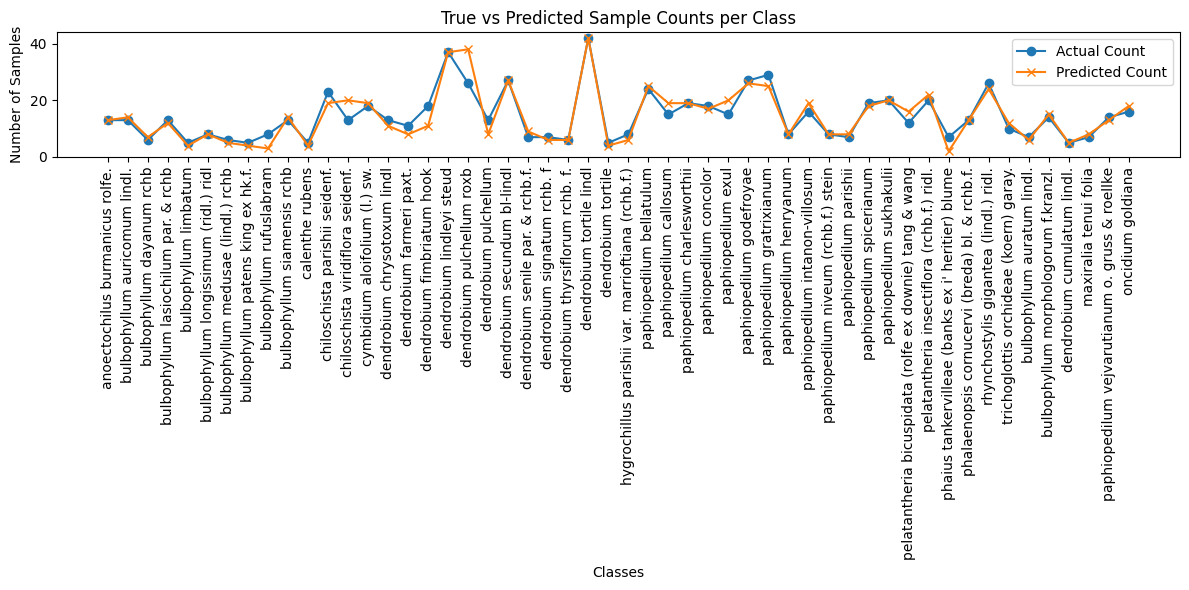

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(x_smooth, true_smooth, label='Actual Count', marker='o')
plt.plot(x_smooth, pred_smooth, label='Predicted Count', marker='x')
plt.xticks(x, class_labels, rotation=90)
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.title('True vs Predicted Sample Counts per Class')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
acc = history_head.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_head.history['loss'] + history_fine.history['loss']
val_loss = history_head.history['val_loss'] + history_fine.history['val_loss']

epochs_range = np.arange(1, len(acc) + 1)

In [ ]:
from scipy.interpolate import make_interp_spline

x_smooth = np.linspace(epochs_range.min(), epochs_range.max(), 300)
spl_acc = make_interp_spline(epochs_range, acc, k=3)
acc_smooth = spl_acc(x_smooth)
spl_val_acc = make_interp_spline(epochs_range, val_acc, k=3)
val_acc_smooth = spl_val_acc(x_smooth)

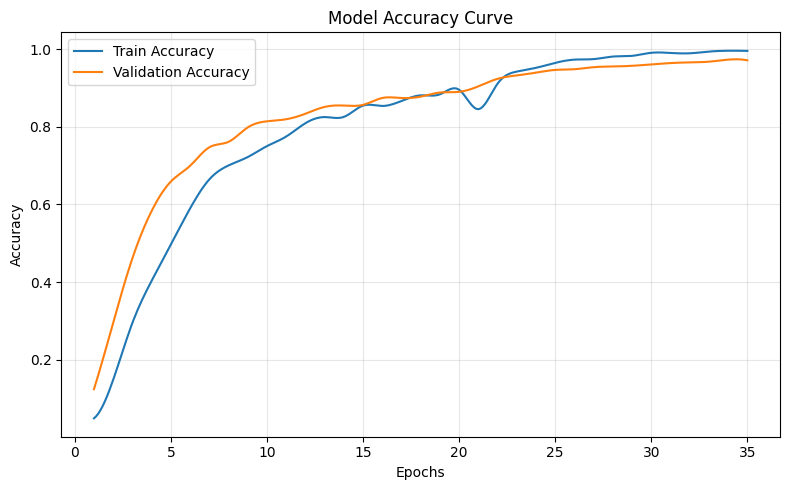

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(x_smooth, acc_smooth, label='Train Accuracy')
plt.plot(x_smooth, val_acc_smooth, label='Validation Accuracy')
plt.title('Model Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()